In [ ]:
!pip install natasha pymorphy2 pandas matplotlib -q

In [ ]:
from collections import Counter
import re
import json

import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
file_path = 'news.csv'

df = pd.read_csv(file_path)

print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (4760, 8)


,guid,title,description,url,published_at,comments_count,created_at_utc,rating
0,7572cce4-05c6-4075-ada9-b10aff6b4fb9,Apple пересмотрела цены на приложения и подпис...,"В блоге для разработчиков Apple\nсообщила\n, ч...",https://habr.com/ru/news/990992/,2026-01-30T11:35:33.000Z,0,2026-01-30T11:50:01.477154+00:00,NaN
1,a76590a7-78af-46e0-b5ce-a103834108f0,С начала работы по выявлению противоправного в...,С момента начала работы по выявлению противопр...,https://habr.com/ru/news/990988/,2026-01-30T11:28:08.000Z,0,2026-01-30T11:50:03.196738+00:00,NaN
2,738423fc-adba-493b-b061-3caf792976ec,"В Rutube зафиксировали более 1,4 млрд сетевых ...",Специалисты по кибербезопасности зафиксировали...,https://habr.com/ru/news/990932/,2026-01-30T10:43:54.000Z,0,2026-01-30T11:50:04.723125+00:00,NaN
3,fe50c699-0a8d-44e1-ac96-4dbc1488d9de,Студия анимации Netflix присоединилась к фонду...,Blender Foundation\nобъявил\nо присоединении а...,https://habr.com/ru/news/990968/,2026-01-30T10:40:08.000Z,0,2026-01-30T11:50:06.406564+00:00,NaN
4,57737b37-f38d-40de-9f22-b11cb3b0b52a,Крупнейшие лейблы подали иск на $13 трлн проти...,Платформа Spotify наряду с «большой тройкой» к...,https://habr.com/ru/news/990914/,2026-01-30T10:17:18.000Z,0,2026-01-30T11:50:07.856969+00:00,NaN


In [ ]:
print("Колонки в датасете:")
print(df.columns.tolist())
print()

print("Пропуски:")
print(df.isna().sum())

Колонки в датасете:
['guid', 'title', 'description', 'url', 'published_at', 'comments_count', 'created_at_utc', 'rating']

Пропуски:
guid                 0
title                0
description          0
url                  0
published_at         0
comments_count       0
created_at_utc       0
rating            4760
dtype: int64


# Далее подготовим текстовые данные:
Пропущенные значения в колонках title и description заменим на nan,также из текста удаляются переносы строк.

Затем заголовок и описание новости объединяются в единое текстовое поле text.

In [ ]:
# препроцессинг текта

# заменяем nan на пустую строку
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')

# заменяем переносы строк на пробелы
df['title'] = df['title'].str.replace('\n', ' ', regex=False)
df['description'] = df['description'].str.replace('\n', ' ', regex=False)

# объединяем заголовок и описание
df['text'] = df['title'] + '. ' + df['description']

# создаем список текстов
texts = df['text'].tolist()

print("Количество текстов:", len(texts))
print()
print("Пример текста:")
print(texts[0])

Количество текстов: 4760

Пример текста:
Apple пересмотрела цены на приложения и подписки в странах с обновлённой налоговой политикой. В блоге для разработчиков Apple сообщила , что пересмотрела цены на приложения и подписки в странах, которые обновили налоговую политику. Изменения касаются в том числе России и Казахстана. Цены увеличат или уменьшат в App Store следующих стран и по следующим причинам: Россия — ставку НДС увеличили с 20% до 22%; Казахстан — ставку НДС увеличили с 12% до 16%; Финляндия и Литва — НДС для аудиокниг, новостей и журналов снизили с 14% до 13,5%; Турция — ставку налога с цифровых продаж снизили с 7,5% до 5%; Зимбабве — НДС увеличили с 15% до 15,5%; Бутан — появился налог на товары и услуги в размере 5%; Гана — власти отменили сбор на борьбу с последствиями COVID-19; Маврикий — теперь Apple обязана платить НДС в размере 15%. Обновлённые цены вступили в силу 29 января 2026 года. Изменения для Маврикия начнут действовать с 16 февраля. Apple отмечает, что новые це

In [ ]:
df[['title', 'description', 'text']].head(3)

,title,description,text
0,Apple пересмотрела цены на приложения и подпис...,"В блоге для разработчиков Apple сообщила , что...",Apple пересмотрела цены на приложения и подпис...
1,С начала работы по выявлению противоправного в...,С момента начала работы по выявлению противопр...,С начала работы по выявлению противоправного в...
2,"В Rutube зафиксировали более 1,4 млрд сетевых ...",Специалисты по кибербезопасности зафиксировали...,"В Rutube зафиксировали более 1,4 млрд сетевых ..."


# Определяем инструменты библиотеки natasha:

Segmenter - сегментация текста

MorphVocab - нормализация слов

NewsEmbeding - ~векторная модель слов (помогает модели уравнивать похожие слова)

NewsMorphTagger - определяет части речи

NewsSyntaxParser - строит синтаксическое дерево предложения


In [ ]:
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    Doc
)

from pymorphy2 import MorphAnalyzer

In [ ]:
# инициализация инструментов natasha
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)

# инициализация pymorphy2
morph = MorphAnalyzer()

In [ ]:
sentence = texts[0]

doc = Doc(sentence)

doc.segment(segmenter)
doc.tag_morph(morph_tagger)
doc.parse_syntax(syntax_parser)

for token in doc.sents[0].tokens:
    print(token.text, token.rel)

Apple nsubj
пересмотрела root
цены obj
на case
приложения nmod
и cc
подписки conj
в case
странах nmod
с case
обновлённой amod
налоговой amod
политикой obl
. punct


# Проверяем работу Natasha.

Видим что все рабоатет как надо:

Apple nsubj - подлежащее

Пересмотнрела root - сказуемое

И так далее:

obj - дополнение

case - предлог

obl - обстоятельство

punct - pyfr ghtgbyfbz


# Далее функция которая будет вытаскивать подлежащее и сказуемое из предложений:

функция parse_sentence выполняет синтаксический разбор предложения и извлекает подлежащее и сказуемое.
Подлежащее определяется по nsubj, а сказуемое — по root.
Если оба элемента найдены, функция возвращает соответствующую пару слов.

In [ ]:
def parse_sentence(sentence, segmenter, morph_tagger, syntax_parser):
    try:
        doc = Doc(sentence)
        doc.segment(segmenter)             #сегментируем теккст
        doc.tag_morph(morph_tagger)        #определяем части речи
        doc.parse_syntax(syntax_parser)    #строим синтаксическое дерево

        for sent in doc.sents:
            subject = None             #подлежащее
            predicate = None           #сказуемое

            for token in sent.tokens:
                if token.rel == 'nsubj' and subject is None:
                    subject = token.text
                if token.rel == 'root' and predicate is None:
                    predicate = token.text

            if subject and predicate:
                return subject, predicate

        return None, None

    except Exception:
        return None, None

In [ ]:
subject, predicate = parse_sentence(
    texts[0],
    segmenter,
    morph_tagger,
    syntax_parser
)

print("Подлежащее:", subject)
print("Сказуемое:", predicate)

Подлежащее: Apple
Сказуемое: пересмотрела


In [ ]:
def build_cooccurrence_dependencies(texts, segmenter, morph_tagger, syntax_parser):

    pairs = []

    for text in texts:

        subject, predicate = parse_sentence(
            text,
            segmenter,
            morph_tagger,
            syntax_parser
        )

        if subject and predicate:
            pairs.append((subject, predicate))

    return Counter(pairs)

In [ ]:
cooccurrences = build_cooccurrence_dependencies(
    texts,
    segmenter,
    morph_tagger,
    syntax_parser
)

In [ ]:
print("Топ-10 сочетаний:")

for (subject, predicate), count in cooccurrences.most_common(10):
    print(f"{subject} - {predicate}: {count}")

Топ-10 сочетаний:
Ученые - разработали: 78
Ученые - создали: 60
Ученые - выяснили: 44
Ученые - обнаружили: 30
Ученые - нашли: 30
ученые - разработали: 24
Ученые - предложили: 23
ученые - создали: 18
Исследователи - разработали: 18
заседание - состоялось: 18


In [ ]:
def visualize_results(counter, top_n=20):

    top_pairs = counter.most_common(top_n)

    labels = [f"{subj} — {pred}" for (subj, pred), _ in top_pairs]
    values = [count for _, count in top_pairs]

    plt.figure(figsize=(10,6))
    plt.barh(labels, values)

    plt.xlabel("Частота")
    plt.title("Наиболее частые сочетания подлежащего и сказуемого")

    plt.gca().invert_yaxis()

    plt.show()

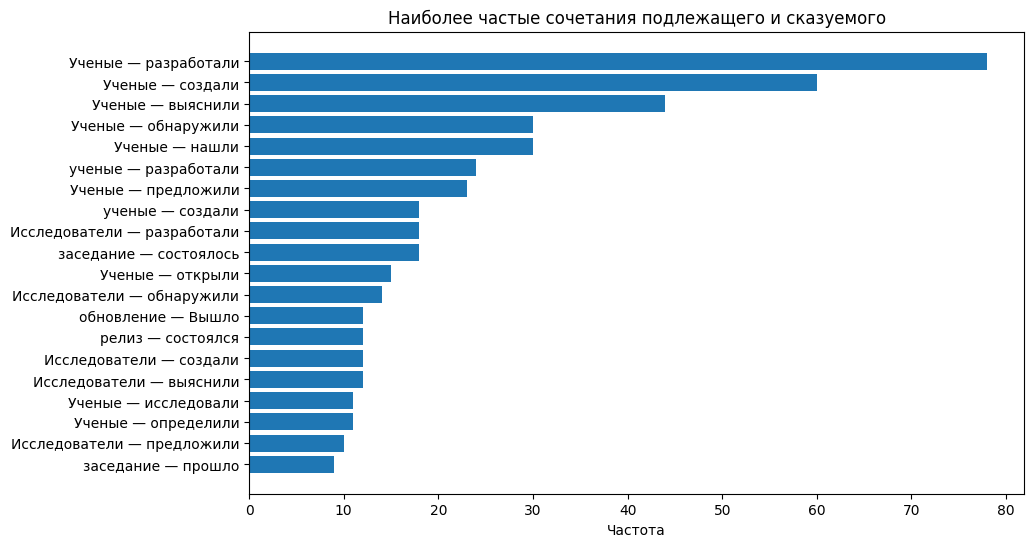

In [ ]:
visualize_results(cooccurrences, top_n=20)

## Вывод:
Наиболее часто встречающимся подлежащим является слово учёные, которое сочетается с такими глаголами как «разработали», «создали», «выяснили», «обнаружили» и «нашли». Это объясняется тем, что значительная часть новостей посвящена научным исследованиям, открытиям и разработкам. Что обьясняется тем что датасет парсился с сатов Scientific Russia и Habr.

Также среди частых сочетаний встречаются конструкции с подлежащим «исследователи», например «исследователи разработали» и «исследователи обнаружили», что подтверждает научную направленность новостных датасета.

Визуализация результатов наглядно демонстрирует распределение частот сочетаний так или иначе связанных с наукой.